#  Notebook 2 — Prétraitement & Analyse Exploratoire
## Prédiction de la polarisation médiatique d'événements géopolitiques

**Objectif (BC4.2)** : Nettoyer, transformer et enrichir les données textuelles pour les rendre exploitables par les algorithmes d'apprentissage automatique.

**Objectif (BC4.3)** : Produire des visualisations informatives et interactives.

## 1. Imports & chargement des données


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import re
import string
import os
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus   import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem     import SnowballStemmer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Optionnel : wordcloud
try:
    from wordcloud import WordCloud
    HAS_WC = True
except ImportError:
    HAS_WC = False

# Téléchargements NLTK
for pkg in ['stopwords','punkt','punkt_tab']:
    nltk.download(pkg, quiet=True)

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = {'Gauche':'#E74C3C','Centre':'#2ECC71','Droite':'#3498DB'}

df = pd.read_csv('data/articles_bruts.csv')
print(f' Dataset chargé : {df.shape}')
df.head(2)

 Dataset chargé : (3000, 19)


,titre,texte,url,source,orientation,label,evenement,date,annee,langue,provenance,nb_mots,nb_caracteres,nb_exclamations,nb_questions,richesse_lexicale,densite_emotionnel,sentiment,subjectivite
0,(CNN) - Barbara Bush made national headlines l...,(CNN) - Barbara Bush made national headlines l...,NaN,Kaggle,Gauche,0,Elections presidentielles USA,2020-01-01,2020,en,Kaggle,119,646,0,0,0.6639,0.0,0.0,0.3
1,"Image source, EPAImage caption, Mr Pompeo than...","Image source, EPAImage caption, Mr Pompeo than...",NaN,Kaggle,Centre,1,Elections presidentielles USA,2020-01-01,2020,en,Kaggle,104,649,0,0,0.6250,0.0,0.0,0.3


## 2. Audit qualité des données


In [2]:
print('=== AUDIT QUALITÉ ===')
print(f'Dimensions        : {df.shape}')
print(f'Valeurs manquantes:\n{df.isnull().sum()[df.isnull().sum()>0]}')
print(f'\nDoublons          : {df.duplicated(subset=["texte"]).sum()}')
print(f'\nTypes de colonnes :')
print(df.dtypes)

# Distribution des classes
dist = df['orientation'].value_counts(normalize=True).mul(100).round(1)
print(f'\nDistribution des classes (%) :')
print(dist)

# Plage temporelle
df['date'] = pd.to_datetime(df['date'])
print(f'\nPériode couverte  : {df["date"].min().date()} → {df["date"].max().date()}')

=== AUDIT QUALITÉ ===
Dimensions        : (3000, 19)
Valeurs manquantes:
titre       1
url      2682
dtype: int64

Doublons          : 505

Types de colonnes :
titre                  object
texte                  object
url                    object
source                 object
orientation            object
label                   int64
evenement              object
date                   object
annee                   int64
langue                 object
provenance             object
nb_mots                 int64
nb_caracteres           int64
nb_exclamations         int64
nb_questions            int64
richesse_lexicale     float64
densite_emotionnel    float64
sentiment             float64
subjectivite          float64
dtype: object

Distribution des classes (%) :
orientation
Gauche    41.2
Centre    31.7
Droite    27.1
Name: proportion, dtype: float64

Période couverte  : 2020-01-01 → 2026-05-07


## 3. Nettoyage avancé du texte (BC4.2 — Fonctions avancées)


In [3]:
STOP_FR = set(stopwords.words('french'))
STOP_EN = set(stopwords.words('english'))
ALL_STOPS = STOP_FR | STOP_EN | {
    'les','des','une','est','que','qui','par','sur','cette',
    'pour','dans','avec','plus','tout','leur','aux','ces','ont'
}
stemmer = SnowballStemmer('french')

def clean_text(text):
    """Pipeline de nettoyage NLP complet."""
    if not isinstance(text, str): return ''
    # 1. Minuscules
    text = text.lower()
    # 2. Suppression des URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Suppression des balises HTML
    text = re.sub(r'<[^>]+>', '', text)
    # 4. Suppression de la ponctuation et chiffres
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', text)
    # 5. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    # 6. Tokenisation + suppression des stopwords
    tokens = [t for t in text.split() if t not in ALL_STOPS and len(t) > 2]
    # 7. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return ' '.join(tokens)

def clean_text_readable(text):
    """Version lisible (sans stemming) — pour les visualisations."""
    if not isinstance(text, str): return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'[^a-zàâçéèêëîïôûùüÿñæœ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in ALL_STOPS and len(t) > 2]
    return ' '.join(tokens)

print(' Nettoyage en cours...')
df['texte_nettoye']  = df['texte'].apply(clean_text)
df['texte_lisible']  = df['texte'].apply(clean_text_readable)
df['titre_nettoye']  = df['titre'].apply(clean_text_readable)
df['texte_complet']  = df['titre_nettoye'] + ' ' + df['texte_nettoye']

print(f' Nettoyage terminé')
print(f'   Exemple avant : {df["texte"].iloc[0][:100]}...')
print(f'   Exemple après : {df["texte_nettoye"].iloc[0][:100]}...')

 Nettoyage en cours...

 Nettoyage terminé
   Exemple avant : (CNN) - Barbara Bush made national headlines last year when she said on NBC that her son Jeb shouldn...
   Exemple après : cnn barbar bush mad national headlin last year said nbc jeb run president lot great famil four famil...


## 4. Re-calcul des scores de sentiment (VADER)


In [4]:
sia = SentimentIntensityAnalyzer()

def get_compound(text):
    return round(sia.polarity_scores(str(text))['compound'], 4)

def get_positivity(text):
    return round(sia.polarity_scores(str(text))['pos'], 4)

def get_negativity(text):
    return round(sia.polarity_scores(str(text))['neg'], 4)

def get_subjectivity(text):
    """TextBlob subjectivity ∈ [0, 1] : 0 = factuel, 1 = très subjectif."""
    try:
        return round(TextBlob(str(text)).sentiment.subjectivity, 4)
    except Exception:
        return 0.0

df['sentiment_vader']   = df['texte'].apply(get_compound)
df['positivite_vader']  = df['texte'].apply(get_positivity)
df['negativite_vader']  = df['texte'].apply(get_negativity)
df['subjectivite']      = df['texte'].apply(get_subjectivity)

print(' Scores VADER + subjectivité TextBlob calculés')
print(df.groupby('orientation')[['sentiment_vader','positivite_vader','negativite_vader','subjectivite']].mean().round(3))

 Scores VADER + subjectivité TextBlob calculés
             sentiment_vader  positivite_vader  negativite_vader  subjectivite
orientation                                                                   
Centre                -0.059             0.035             0.052         0.175
Droite                -0.063             0.038             0.056         0.231
Gauche                 0.157             0.122             0.056         0.294


## 5. Feature Engineering — Extraction de variables


In [5]:
def lexical_richness(text):
    words = str(text).split()
    return round(len(set(words)) / max(len(words), 1), 4)

def political_vocabulary_score(text, orientation):
    """Score de vocabulaire politique typique par orientation."""
    vocab = {
        'Gauche':  ['droit','justice','solidarit','egalit','social','lutt','opprim'],
        'Centre':  ['analys','expert','rapport','confirm','strateg','negoci'],
        'Droite':  ['securit','souverain','national','frontier','identit','menac','ordre']
    }
    tokens = str(text).lower().split()
    score = sum(1 for t in tokens if any(kw in t for kw in vocab.get(orientation, [])))
    return round(score / max(len(tokens), 1), 4)

df['richesse_lexicale']  = df['texte_nettoye'].apply(lexical_richness)
df['score_vocab_gauche'] = df['texte'].apply(lambda t: political_vocabulary_score(t, 'Gauche'))
df['score_vocab_centre'] = df['texte'].apply(lambda t: political_vocabulary_score(t, 'Centre'))
df['score_vocab_droite'] = df['texte'].apply(lambda t: political_vocabulary_score(t, 'Droite'))

# Ratio polarisation : écart entre score extrême max et centre
df['indice_polarisation'] = df.apply(
    lambda r: round(max(r['score_vocab_gauche'], r['score_vocab_droite']) - r['score_vocab_centre'], 4),
    axis=1
)

print(' Feature engineering terminé')
feature_cols = ['sentiment_vader','subjectivite','richesse_lexicale',
                'densite_emotionnel','indice_polarisation']
print(df.groupby('orientation')[feature_cols].mean().round(3))

 Feature engineering terminé
             sentiment_vader  subjectivite  richesse_lexicale  \
orientation                                                     
Centre                -0.059         0.175              0.941   
Droite                -0.063         0.231              0.937   
Gauche                 0.157         0.294              0.923   

             densite_emotionnel  indice_polarisation  
orientation                                           
Centre                    0.010               -0.031  
Droite                    0.023                0.046  
Gauche                    0.040                0.031  


## 6. Analyse Exploratoire des Données (EDA)
### 6.1 Distribution des orientations et événements


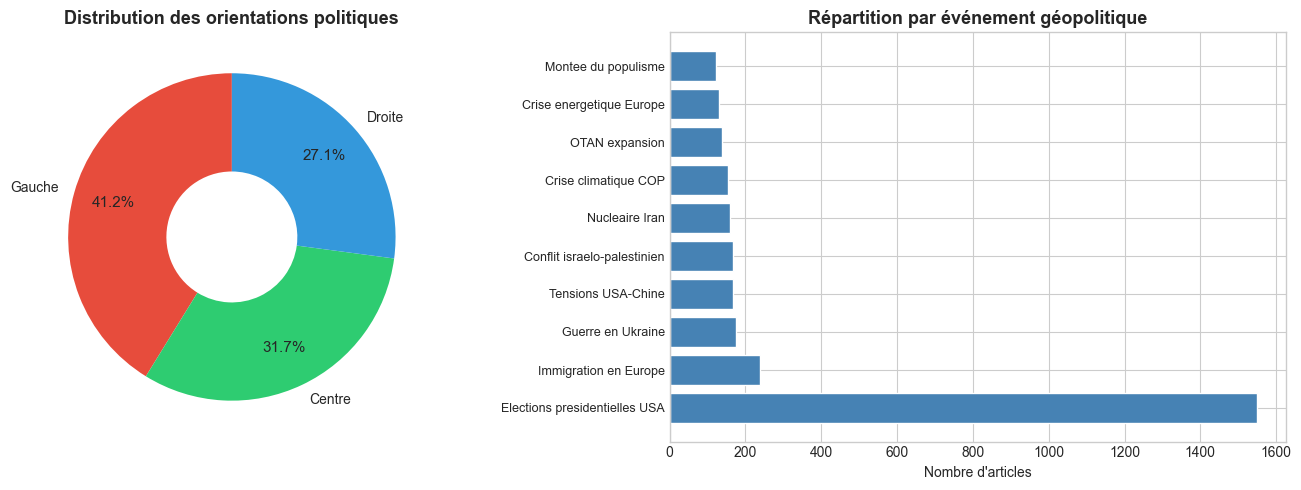

 Figure sauvegardée


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des orientations
counts = df['orientation'].value_counts()
colors = [PALETTE[o] for o in counts.index]
wedges, texts, autotexts = axes[0].pie(
    counts.values, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)
for at in autotexts: at.set_fontsize(11)
axes[0].set_title('Distribution des orientations politiques', fontsize=13, fontweight='bold')

# Distribution par événement
ev_counts = df['evenement'].value_counts()
axes[1].barh(ev_counts.index, ev_counts.values, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Nombre d\'articles')
axes[1].set_title('Répartition par événement géopolitique', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig('data/fig_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée')

### 6.2 Scores de sentiment par orientation


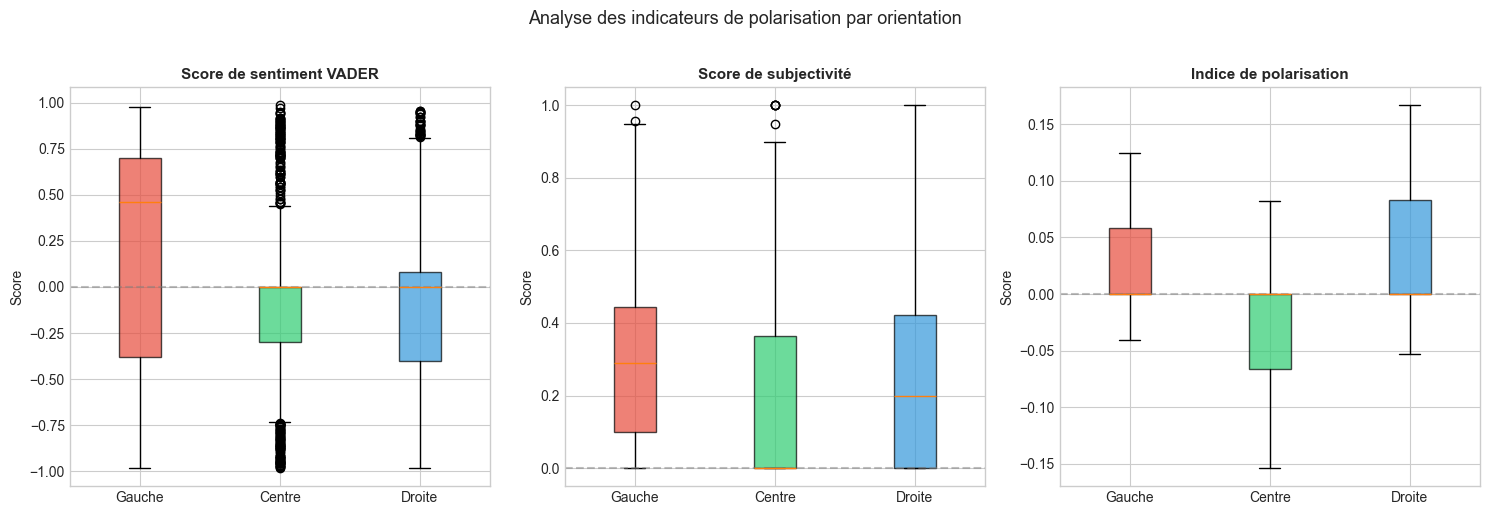

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('sentiment_vader', 'Score de sentiment VADER', 'coolwarm'),
    ('subjectivite', 'Score de subjectivité', 'RdYlGn'),
    ('indice_polarisation', 'Indice de polarisation', 'Purples')
]

for ax, (col, title, cmap) in zip(axes, metrics):
    data_by_orient = [df[df['orientation']==o][col].values for o in ['Gauche','Centre','Droite']]
    bp = ax.boxplot(data_by_orient, labels=['Gauche','Centre','Droite'],
                    patch_artist=True, notch=False)
    colors_list = [PALETTE['Gauche'], PALETTE['Centre'], PALETTE['Droite']]
    for patch, color in zip(bp['boxes'], colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Score')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Analyse des indicateurs de polarisation par orientation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/fig_sentiment_boxplot.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.3 Évolution temporelle de la polarisation


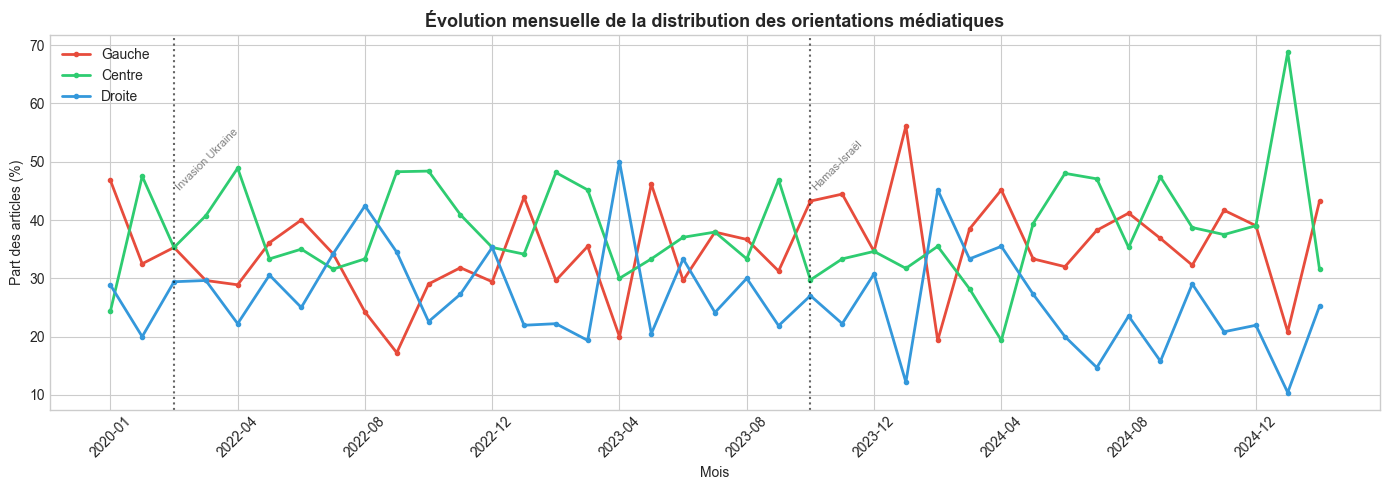

In [8]:
df_time = df.copy()
df_time['mois_annee'] = df_time['date'].dt.to_period('M').astype(str)

# Proportion mensuelle de chaque orientation
monthly = (df_time.groupby(['mois_annee','orientation'])
           .size().unstack(fill_value=0))
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
for orient, color in PALETTE.items():
    if orient in monthly_pct.columns:
        ax.plot(monthly_pct.index, monthly_pct[orient],
                label=orient, color=color, linewidth=2, marker='o', markersize=3)

# Annotations des événements clés
events_markers = {'2022-02': 'Invasion Ukraine', '2023-10': 'Hamas-Israël'}
for m, ev in events_markers.items():
    if m in monthly_pct.index:
        ax.axvline(x=m, color='black', linestyle=':', alpha=0.6)
        ax.annotate(ev, xy=(m, 45), fontsize=8, rotation=45, color='gray')

ax.set_xlabel('Mois')
ax.set_ylabel('Part des articles (%)')
ax.set_title('Évolution mensuelle de la distribution des orientations médiatiques',
             fontsize=13, fontweight='bold')
ax.legend()
ax.set_xticks(ax.get_xticks()[::4])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/fig_evolution_temporelle.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.4 Matrice de corrélation des features


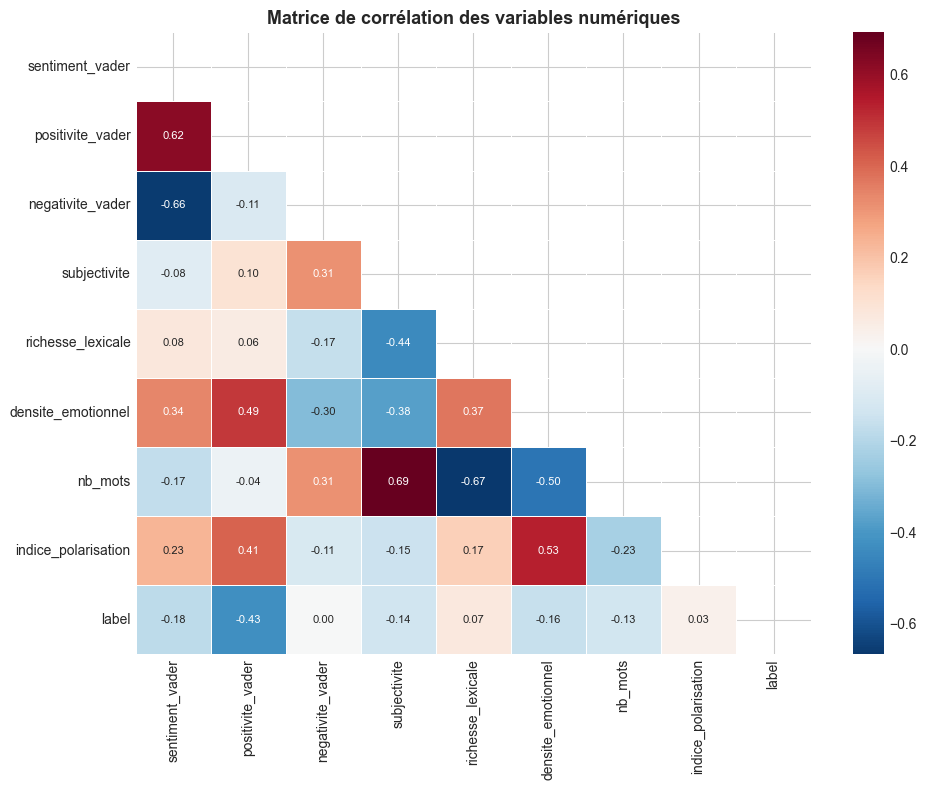

In [9]:
num_features = ['sentiment_vader','positivite_vader','negativite_vader',
                 'subjectivite','richesse_lexicale','densite_emotionnel',
                 'nb_mots','indice_polarisation','label']

corr_matrix = df[num_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation des variables numériques',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data/fig_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

### 6.5 Nuage de mots par orientation (WordCloud)


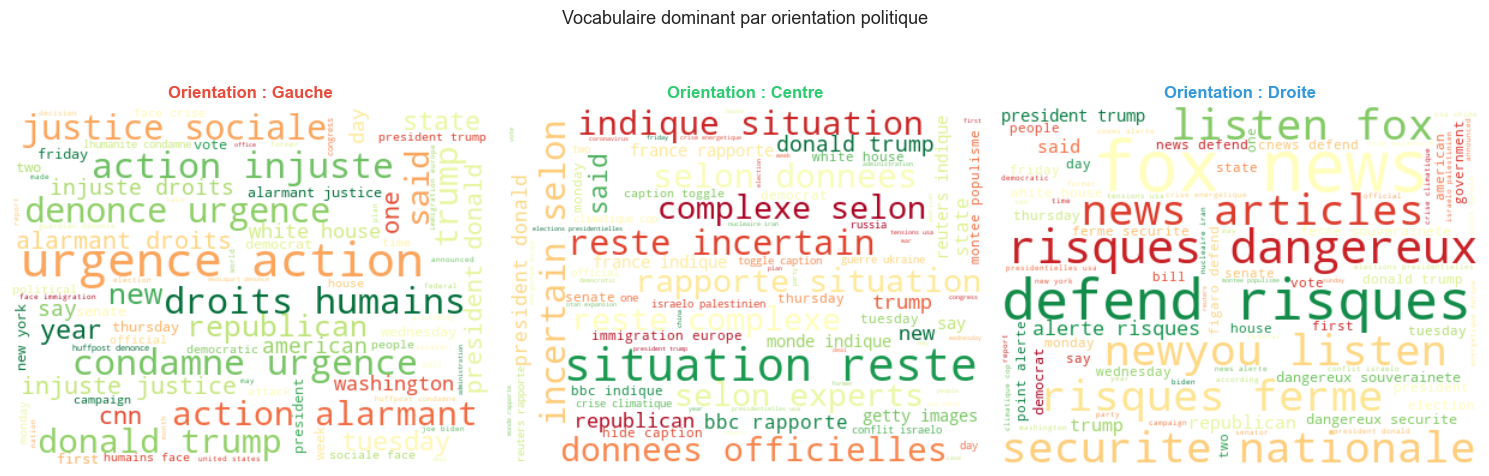

In [10]:
if HAS_WC:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (orient, color) in zip(axes, PALETTE.items()):
        text_corpus = ' '.join(df[df['orientation']==orient]['texte_lisible'].dropna())
        wc = WordCloud(width=400, height=300, background_color='white',
                       max_words=80, colormap='RdYlGn',
                       prefer_horizontal=0.8).generate(text_corpus)
        ax.imshow(wc, interpolation='bilinear')
        ax.axis('off')
        ax.set_title(f'Orientation : {orient}', fontsize=12,
                     fontweight='bold', color=color)
    plt.suptitle('Vocabulaire dominant par orientation politique',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('data/fig_wordcloud.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('WordCloud non installé — pip install wordcloud')
    # Alternative : top mots par fréquence
    from collections import Counter
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (orient, color) in zip(axes, PALETTE.items()):
        words = ' '.join(df[df['orientation']==orient]['texte_lisible'].dropna()).split()
        top = Counter(words).most_common(15)
        words_top, counts = zip(*top)
        ax.barh(words_top[::-1], counts[::-1], color=color, alpha=0.8)
        ax.set_title(f'{orient} — Top mots', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/fig_top_mots.png', dpi=120, bbox_inches='tight')
    plt.show()

## 7. Vectorisation TF-IDF


In [11]:
# TF-IDF sur le texte complet (titre + corps nettoyé)
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrammes et bigrammes
    sublinear_tf=True,    # log-scaling de TF
    min_df=3,             # ignore les termes très rares
    max_df=0.90           # ignore les termes trop fréquents
)

X_tfidf = tfidf.fit_transform(df['texte_complet'])
print(f' Matrice TF-IDF : {X_tfidf.shape}')
print(f'   (articles × features textuelles)')

# Top features par importance globale
feature_names = tfidf.get_feature_names_out()
tfidf_means   = np.asarray(X_tfidf.mean(axis=0)).flatten()
top_idx       = tfidf_means.argsort()[-20:][::-1]
print(f'\nTop 20 features TF-IDF : {list(feature_names[top_idx])}')

 Matrice TF-IDF : (3000, 5000)
   (articles × features textuelles)

Top 20 features TF-IDF : ['trump', 'usa', 'president', 'rest', 'situat', 'selon', 'situat rest', 'action', 'fac', 'urgenc', 'urgenc action', 'new', 'iran', 'risqu', 'fox', 'europe', 'otan', 'europ', 'rest incertain', 'incertain']


## 8. Réduction dimensionnelle — Visualisation LSA


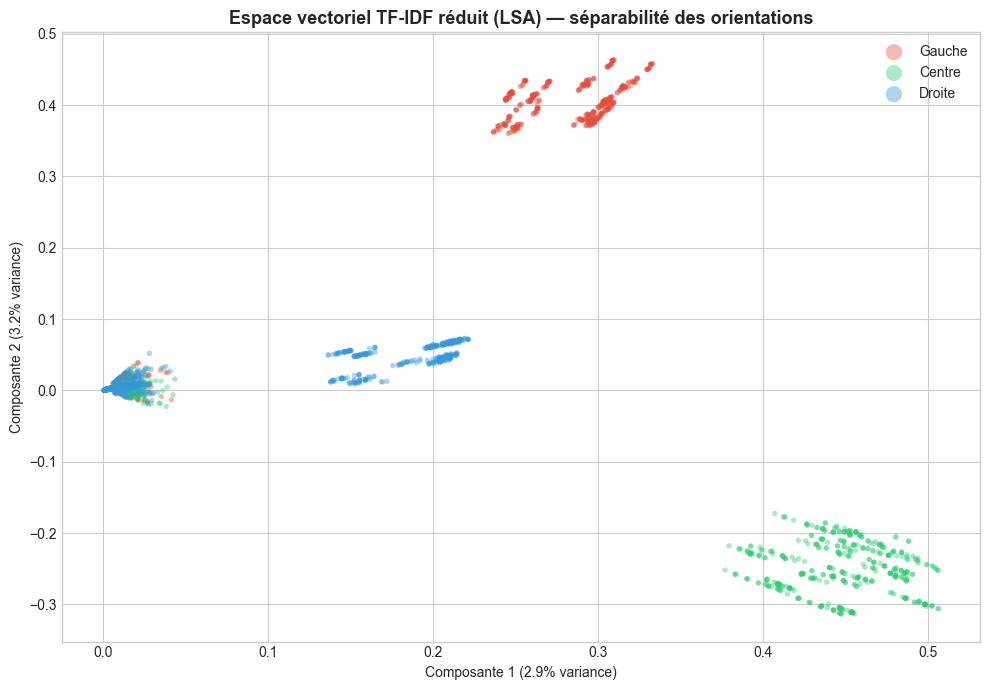

Variance expliquée totale : 6.1%


In [12]:
# Réduction à 2 dimensions pour visualisation
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

fig, ax = plt.subplots(figsize=(10, 7))
for orient, color in PALETTE.items():
    mask = df['orientation'] == orient
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=color, label=orient, alpha=0.4, s=15, edgecolors='none')

ax.set_xlabel(f'Composante 1 ({svd.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Composante 2 ({svd.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Espace vectoriel TF-IDF réduit (LSA) — séparabilité des orientations',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=3)
plt.tight_layout()
plt.savefig('data/fig_lsa_2d.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Variance expliquée totale : {svd.explained_variance_ratio_.sum()*100:.1f}%')

## 9. Sauvegarde du dataset prétraité


In [13]:
import scipy.sparse as sp, pickle

# Sauvegarder le DataFrame enrichi
df.to_csv('data/articles_preprocesses.csv', index=False, encoding='utf-8')

# Sauvegarder la matrice TF-IDF et le vectoriseur
sp.save_npz('data/tfidf_matrix.npz', X_tfidf)
with open('data/tfidf_vectorizer.pkl','wb') as f:
    pickle.dump(tfidf, f)

print(' Fichiers sauvegardés :')
print('   data/articles_preprocesses.csv')
print('   data/tfidf_matrix.npz')
print('   data/tfidf_vectorizer.pkl')
print(f'\nDataset final : {df.shape[0]} articles × {df.shape[1]} colonnes')
df[['orientation','sentiment_vader','subjectivite','richesse_lexicale',
    'indice_polarisation']].describe().round(3)

 Fichiers sauvegardés :
   data/articles_preprocesses.csv
   data/tfidf_matrix.npz
   data/tfidf_vectorizer.pkl

Dataset final : 3000 articles × 30 colonnes


,sentiment_vader,subjectivite,richesse_lexicale,indice_polarisation
count,3000.000,3000.000,3000.000,3000.000
mean,0.029,0.239,0.933,0.015
std,0.522,0.223,0.088,0.060
min,-0.982,0.000,0.469,-0.154
25%,-0.382,0.000,0.884,0.000
50%,0.000,0.200,0.976,0.000
75%,0.459,0.417,1.000,0.041
max,0.985,1.000,1.000,0.167


## 10. Résumé — Critères BC4.2 / BC4.3
| Critère | Réalisé |
|---------|--------|
| **C3** — Fonctions avancées de nettoyage |  Pipeline 7 étapes + stemming + stopwords |
| **C4** — Données prêtes pour ML |  TF-IDF (5000 feat.), 8 features numériques |
| **C5** — Visualisations informatives |  5 figures : distribution, sentiment, LSA, corrélation, wordcloud |